# Question 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

### PART 1
Write an ADQL query that returns all stars in the Gaia DR3 gaiadr3.gaia_source
table within 1 degree of M67 with G < 14 (phot_g_mean__mag) and crossmatches them with 2MASS (gaiadr1.tmass_original_valid). You can execute the query on the Gaia archive website or via astroquery. Include your ADQL query in the notebook and report the number of returned stars.

In [ ]:
# Query
query = """
SELECT *
FROM gaiadr3.gaia_source AS gaia
JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch
    ON gaia.source_id = xmatch.source_id
JOIN gaiadr1.tmass_original_valid AS tmass
    ON xmatch.original_ext_source_id = tmass.designation
WHERE 1 = CONTAINS(
   POINT(132.825, 11.8),
   CIRCLE(gaia.ra, gaia.dec, 1.0))
AND phot_g_mean_mag < 14
"""

# Send query to Gaia archive 
job = Gaia.launch_job_async(query)
results = job.get_results()
print(f"Number of stars: {len(results)}")


INFO: Query finished. [astroquery.utils.tap.core]
Number of returned stars: 1018


### PART 2

Identify stars with:

• bad 2MASS photometry (ph_qual is not ’AAA’);

• non-positive values of Gaia parallax.

Apply these quality cuts and report how many stars remain.

In [3]:
# Query
query = """
SELECT *
FROM gaiadr3.gaia_source AS gaia
JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch
    ON gaia.source_id = xmatch.source_id
JOIN gaiadr1.tmass_original_valid AS tmass
    ON xmatch.original_ext_source_id = tmass.designation
WHERE 1 = CONTAINS(
   POINT(132.825, 11.8),
   CIRCLE(gaia.ra, gaia.dec, 1.0))
AND phot_g_mean_mag < 14
AND tmass.ph_qual = 'AAA'
AND parallax > 0
"""

# Send query to Gaia archive 
job = Gaia.launch_job_async(query)
cleaned_results = job.get_results()
print(f"Number of stars: {len(cleaned_results)}")

INFO: Query finished. [astroquery.utils.tap.core]
Number of returned stars: 988


### PART 3
Create and save a two-panel figure showing:

• Gaia BP−RP versus absolute G magnitude, using bp_rp;

• 2MASS J−Ks versus apparent H magnitude, using j_m, h_m, and ks_m.

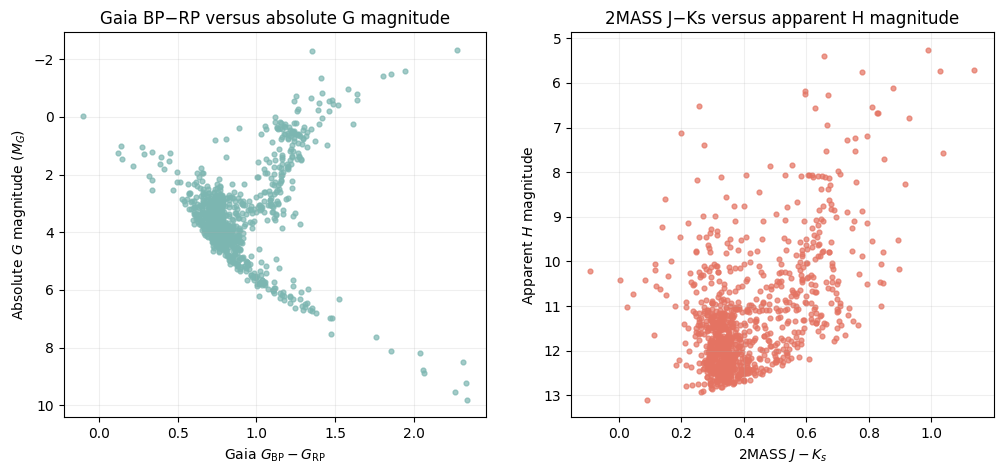

In [4]:
# Convert results from astroquery to dataframe
data = cleaned_results.to_pandas()

# Convert apparent G magnitude to absolute G magnitude using parallax
data["absolute_g"] = (data["phot_g_mean_mag"] + 5 * np.log10(data["parallax"]) - 10)

# Calculate J-Ks
data["j_minus_ks"] = data["j_m"] - data["ks_m"]

# Create two-panel figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Gaia BP−RP versus absolute G magnitude
axes[0].scatter(data["bp_rp"], data["absolute_g"], s=12, alpha=0.7, color="#7CB6B1")
axes[0].set_xlabel(r"Gaia $G_{\rm BP}-G_{\rm RP}$")
axes[0].set_ylabel(r"Absolute $G$ magnitude ($M_G$)")
axes[0].set_title("Gaia BP−RP versus absolute G magnitude")
axes[0].invert_yaxis()
axes[0].grid(alpha=0.2)

# Plot 2: 2MASS J−Ks versus apparent H magnitude
axes[1].scatter(data["j_minus_ks"], data["h_m"], s=12, alpha=0.7, color="#E47362")
axes[1].set_xlabel(r"2MASS $J-K_s$")
axes[1].set_ylabel(r"Apparent $H$ magnitude")
axes[1].set_title("2MASS J−Ks versus apparent H magnitude")
axes[1].invert_yaxis()
axes[1].grid(alpha=0.2)

# Save and plot figure
fig.savefig("figures/colour_magnitude_diagrams.png")
plt.show()

### PART 4

Based only on fibre usage, would you recommend this field for a 2dF/HERMES observing proposal? Support your answer quantitatively.

HERMES can simultaneously get spectra of 392 different stars within a 2 degree field (https://aat.anu.edu.au/science/instruments/current/HERMES) and there are 988 stars in this 1 degree field. For all targets to be observed it must be done 3 times which will mean that there are 1176 available fibres ($392*3$). If 988 are used, this gives a fibre usage of $988/1176 = 84\%$ which is relatively high. This means that this observing proposal has enough targets to ensure that HERMES is used efficiently.